In [22]:
import numpy as np
import json

#ジャンルリスト
genre_list = ["中華", "居酒屋", "ダイニングバー・バル", "和食", "お好み焼き・もんじゃ",
              "韓国料理", "イタリアン・フレンチ", "焼肉・ホルモン", "洋食", "カフェ・スイーツ", "アジア・エスニック料理", 
              "創作料理", "バー・カクテル", "各国料理", "カラオケ・パーティ", "ラーメン"]

# ユーザーの特徴ベクトル
with open('user3.json', 'r') as f:
    user_data = json.load(f)

scaled_junre = [(user_data[genre] - 1) / (3 - 1) for genre in genre_list]
scaled_price = (user_data["価格帯"] - 1) / (5 - 1)

user_profile = np.append(scaled_junre, scaled_price)

#ユーザーの飲食店に対する評価ベクトル
user_ratings = np.array(user_data["評価"])

# レストランベクトルの情報
with open('selected_shops.json', 'r') as f:
    shop_info = json.load(f)
# レストランベクトルの作成
with open('transformed_100shops.json', 'r') as f:
    shop_data = json.load(f)

restaurants = []
for shop in shop_data:    
    genre_vector = [shop[genre] for genre in genre_list]
    price = shop["価格帯"]
    shop_vector = np.append(genre_vector, price)
    restaurants.append(shop_vector)
restaurants = np.array(restaurants)

#ジャンルのインデックスを返す
def genreIndex(restaurant):
    genre_index = -1
    for i in range(16):
        if restaurant[i] == 1:
            genre_index = i
    return genre_index

# 重み付きユークリッド距離を計算する関数
def weighted_euclidean_distance(user_profile, restaurant, min_genre_distance, weights):
    return np.sqrt(weights[0]*(min_genre_distance**2) + weights[1]*((restaurant[16] - user_profile[16])**2))

# 正規化関数 (1 - 5の範囲にする)
def normalize_distance(distance):
    return 5 - 4 * distance
    
#共通処理
def run_process(restaurant, weights, rating, total_err, total_squared_err):
   #ジャンルとの距離
    genre_index = genreIndex(restaurant)
    genre_distance = abs(restaurant[genre_index] - user_profile[genre_index])

    # 重み付きユークリッド距離を計算
    distance = weighted_euclidean_distance(user_profile, restaurant, genre_distance, weights)

    # 予測評価値を計算
    predicted_rating = normalize_distance(distance)
    
    # 評価の差
    rating_difference = predicted_rating - rating
    
    #絶対値誤差を加算
    total_err += abs(rating_difference)

    #二乗誤差を加算
    total_squared_err += rating_difference ** 2

    return rating_difference, distance, genre_distance, total_err, total_squared_err, predicted_rating


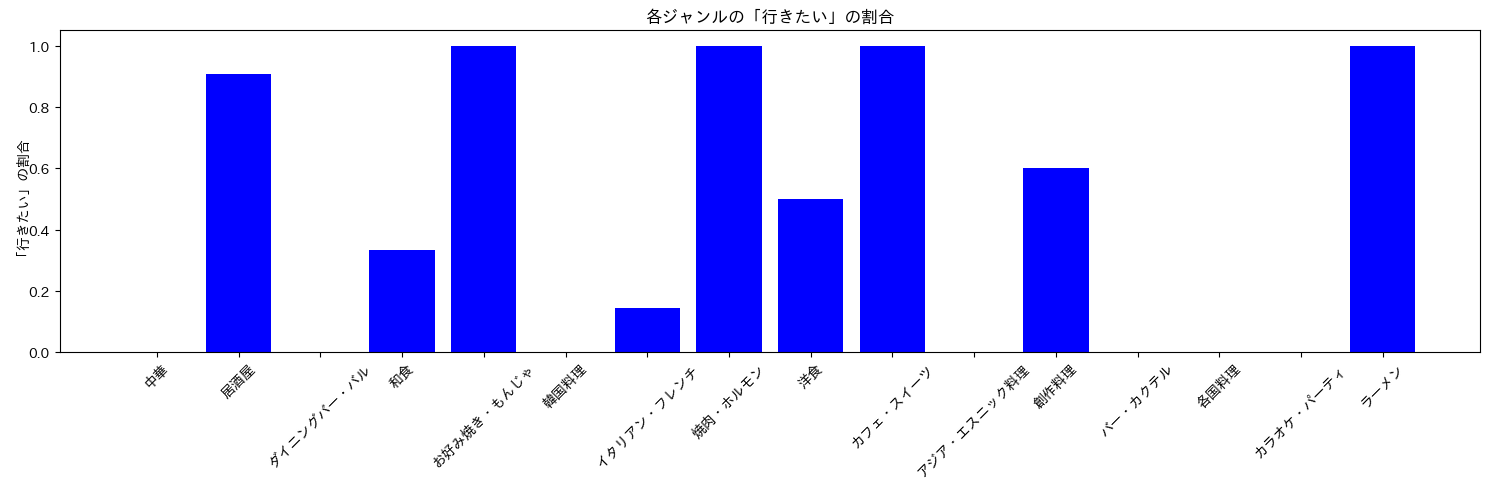

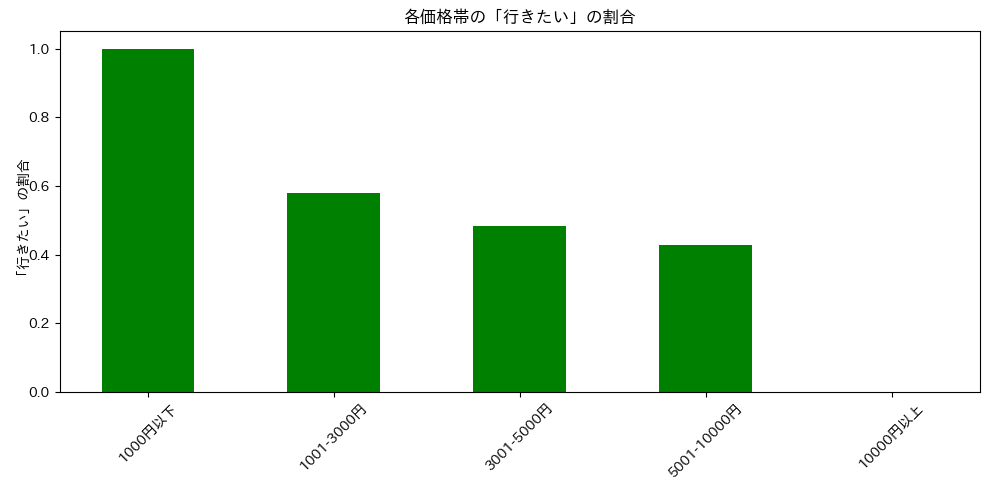

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import japanize_matplotlib

# 1, 2, 3を0に、4, 5を1に変換
converted_ratings = np.where(user_ratings <= 3, 0, 1)

# 各ジャンルの「行きたい」の割合を計算
genre_ratios = []
non_zero_one_indices = []
for i, genre in enumerate(genre_list):
    mask = restaurants[:, i] == 1
    want_to_go_count = np.sum(converted_ratings[mask] == 1)
    total_count = np.sum(mask)
    
    ratio = want_to_go_count / total_count if total_count > 0 else 0
    genre_ratios.append(ratio)
    # このジャンルの「行きたい」の割合が0か1でない場合、そのrestaurantsのインデックスを保存
    if 0 < ratio < 1:
        non_zero_one_indices.extend(np.where(mask)[0])
selected_shops = [shop_info[index] for index in non_zero_one_indices]
selected_ratings = [converted_ratings[index] for index in non_zero_one_indices]

for i, genre in enumerate(genre_list):
    mask = restaurants[:, i] == 1
    want_to_go_count = np.sum(converted_ratings[mask] == 1)
    total_count = np.sum(mask)
    
    ratio = want_to_go_count / total_count if total_count > 0 else 0

# 各価格帯の「行きたい」の割合を計算
price_ratios = []
price_labels = ["1000円以下", "1001-3000円", "3001-5000円", "5001-10000円", "10000円以上"]
for price in [0, 0.25, 0.5, 0.75, 1.0]:
    mask = restaurants[:, -1] == price
    want_to_go_count = np.sum(converted_ratings[mask] == 1)
    total_count = np.sum(mask)
    
    ratio = want_to_go_count / total_count if total_count > 0 else 0
    price_ratios.append(ratio)

# ジャンルごとの「行きたい」の割合を棒グラフで表示
plt.figure(figsize=(15, 5))
plt.bar(genre_list, genre_ratios, color='b')
plt.ylabel("「行きたい」の割合")
plt.title("各ジャンルの「行きたい」の割合")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 価格帯ごとの「行きたい」の割合を棒グラフで表示
plt.figure(figsize=(10, 5))
plt.bar(price_labels, price_ratios, color='g', width=0.5)  # widthを調整して棒の間隔を開けます
plt.ylabel("「行きたい」の割合")
plt.title("各価格帯の「行きたい」の割合")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [25]:
def train(restaurants_train, ratings_train, learning_rate):
    
    # 初期化
    weights = np.array([0.5, 0.5])      
    gradients = np.zeros(2)
    total_err_train = 0
    total_squared_err_train = 0
    mae_train = 0 
    rmse_train = 0   
    
    for i in range(len(restaurants_train)):   
        rating_difference, distance, genre_distance, total_err_train, total_squared_err_train, _ = run_process(restaurants_train[i], weights, ratings_train[i], total_err_train, total_squared_err_train)
        
        gradients[0] = -4 * rating_difference * (1/(distance+1e-8)) * (genre_distance**2)
        gradients[1] = -4 * rating_difference * (1/(distance+1e-8)) * ((user_profile[16] - restaurants_train[i][16])**2)

        # 重みの更新
        weights -= learning_rate * gradients

        # 重みを非負にクリッピング
        weights = np.maximum(weights, 0)

        # 重みを正規化
        weights /= np.sum(weights)
    
    mae_train = total_err_train/len(restaurants_train)
    rmse_train = total_squared_err_train/len(restaurants_train)

    return weights, mae_train, rmse_train

def test(restaurants_test, ratings_test, weights):    

    total_err_test = 0
    total_squared_err_test = 0
    predicted_ratings = []
    k = 5

    for i in range(len(restaurants_test)):
        
        _,  _, _, total_err_test, total_squared_err_test, predicted_rating = run_process(restaurants_test[i], weights, ratings_test[i], total_err_test, total_squared_err_test)
        predicted_ratings.append(predicted_rating)

    mae_test = total_err_test/len(restaurants_test)
    rmse_test = total_squared_err_test/len(restaurants_test)
    
    predicted_ratings = np.array(predicted_ratings)
    top_k_indices = np.argsort(predicted_ratings)[-k:]
    
    top_k_ratings_test = np.array(ratings_test)[top_k_indices]
    precision_k = np.sum(top_k_ratings_test >= 5) / k
    
    total_high_rated = np.sum(np.array(ratings_test) >= 5)
    recall_k = np.sum(top_k_ratings_test >= 5) / total_high_rated if total_high_rated > 0 else 0

    return mae_test, rmse_test, precision_k, recall_k

In [26]:
from sklearn.model_selection import KFold

# K-Fold交差検証の設定
k = 5 
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for train_index, test_index in kf.split(restaurants):
    # 訓練用とテスト用のデータに分割
    restaurants_train, restaurants_test = restaurants[train_index], restaurants[test_index]
    ratings_train, ratings_test = user_ratings[train_index], user_ratings[test_index]

    # 初期の重みで訓練前の結果を得る
    initial_weights = np.array([0.5, 0.5])
    mae_before_train, rmse_before_train, precision_k_before_train, recall_k_before_train = test(restaurants_test, ratings_test, initial_weights)
    print("mae_before_train:"+ str(mae_before_train))
    #訓練後
    weights, mae_train, rmse_train = train(restaurants_train, ratings_train, 0.001)
    print("mae_train:"+ str(mae_train))

    #テスト
    mae_test, rmse_test, precision_k, recall_k = test(restaurants_test, ratings_test, weights)

2.41886116991581
0.0
0.1715728752538097
0.8284271247461903
1.0
1.8786796564403576
0.7071067811865479
0.0
0.7071067811865479
0.41886116991581
1.1715728752538097
1.0
0.08452405257734963
0.7071067811865479
0.1715728752538097
0.7071067811865479
0.0
1.585786437626905
0.4142135623730949
0.7071067811865479
mae_before_train:0.7339802852644843
0.0
0.1715728752538097
0.4184013048550659
1.082259964108831
0.41541225338227594
0.0
0.454442497274655
0.2954240984016767
1.0
0.1620803602914651
1.1608024925756477
0.7021111780175744
0.0
0.2982503588280032
0.0
0.29809674471160186
1.0
0.4242023685119283
0.45687213826979933
0.7028250759108801
1.5873343593252196
1.4554654650958025
1.4540345151548757
0.0
0.4168056939631679
0.41643477798971507
1.0
0.0
0.9230252240149541
0.08304993864532983
0.0
1.418115364826546
1.41684978769422
1.1618357084467839
1.4236287115189317
2.0
0.0
0.0
2.2962233813239816
1.1629391591476188
1.1538232517821179
0.14489422023611986
0.14377931263829913
0.8182975071900334
1.1385265008737537
0

In [6]:
from pptx import Presentation
from pptx.util import Inches

# 結果を保存するリストを初期化
metrics_list = []

for train_index, test_index in kf.split(restaurants):
    # 訓練用とテスト用のデータに分割
    restaurants_train, restaurants_test = restaurants[train_index], restaurants[test_index]
    ratings_train, ratings_test = user_ratings[train_index], user_ratings[test_index]

    weights, mae_train, rmse_train = train(restaurants_train, ratings_train)
    print(weights)
    mae_test, rmse_test, precision_k, recall_k = test(restaurants_test, ratings_test, weights)
    
    # 各メトリクスをリストに追加
    metrics_list.append([mae_train, rmse_train, mae_test, rmse_test, precision_k, recall_k])

[0.64155188 0.35844812]
[0.62794113 0.37205887]
[0.53370704 0.46629296]
[0.52868278 0.47131722]
[0.58249896 0.41750104]
